# 🔹 Step 1: Setup & Data Loading


In [ ]:
import pandas as pd
import numpy as np

from google.colab import files

uploaded = files.upload()

df = pd.read_csv('top_insta_influencers_data set 2.csv')

df.head()


Saving top_insta_influencers_data set 2.csv to top_insta_influencers_data set 2.csv


,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States


# 🔹 Step 2: Data Cleaning & Preprocessing


In [ ]:
# Replace shorthand notations with scientific notation
replace_dict = {'b': 'e9', 'm': 'e6', 'k': 'e3', '%': ''}

columns_to_convert = ['total_likes', 'posts', 'followers',
                      'avg_likes', '60_day_eng_rate', 'new_post_avg_like']

df[columns_to_convert] = df[columns_to_convert].replace(replace_dict, regex=True).astype(float)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

#  Fill missing values safely (avoiding inplace warning)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

#  Confirm final structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rank               200 non-null    int64  
 1   channel_info       200 non-null    object 
 2   influence_score    200 non-null    int64  
 3   posts              200 non-null    float64
 4   followers          200 non-null    float64
 5   avg_likes          200 non-null    float64
 6   60_day_eng_rate    200 non-null    float64
 7   new_post_avg_like  200 non-null    float64
 8   total_likes        200 non-null    float64
 9   country            200 non-null    object 
dtypes: float64(6), int64(2), object(2)
memory usage: 15.8+ KB


# 🔹 Step 3: Exploratory Data Analysis (EDA)


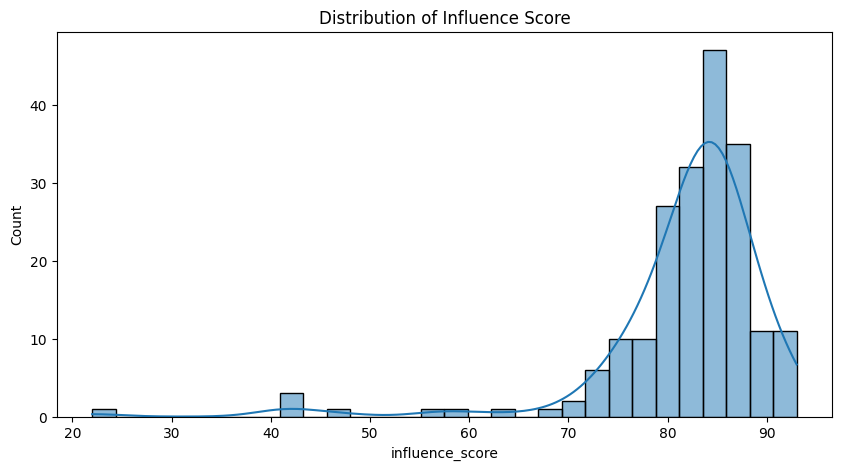

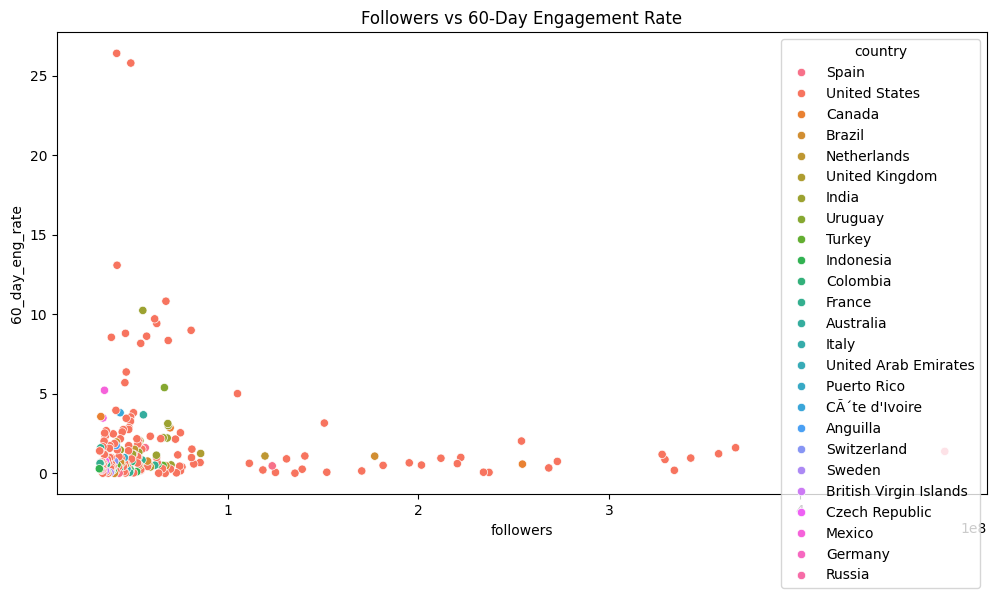

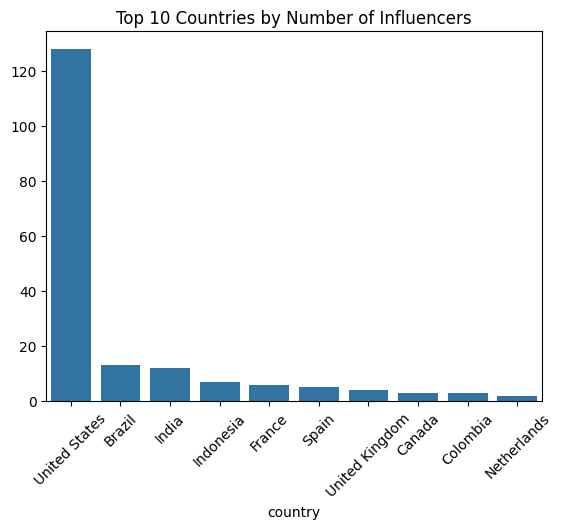

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Influence Scores
plt.figure(figsize=(10, 5))
sns.histplot(df['influence_score'], bins=30, kde=True)
plt.title('Distribution of Influence Score')
plt.show()

# Followers vs 60-day engagement rate
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='followers', y='60_day_eng_rate', hue='country')
plt.title('Followers vs 60-Day Engagement Rate')
plt.show()

# Top 10 countries with most influencers
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Number of Influencers')
plt.show()


# 🔹 Step 4: Feature Engineering


In [ ]:
df['like_follower_ratio'] = df['total_likes'] / df['followers']
df['post_follower_ratio'] = df['posts'] / df['followers']
df['avg_likes_ratio'] = df['avg_likes'] / df['followers']


# 🔹 Step 5: Model Building (Predicting influence_score)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Features & target
X = df[['followers', 'avg_likes', '60_day_eng_rate', 'new_post_avg_like',
        'like_follower_ratio', 'post_follower_ratio']]
y = df['influence_score']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MSE: 171.57413
R²: -0.014814953920542884


# 🔹 Step 6: Feature Importance


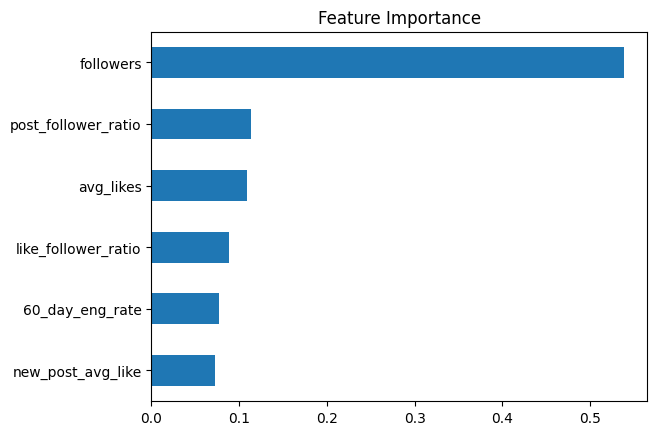

In [ ]:
pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()


# 🔹 Step 7: Predictions vs Actuals


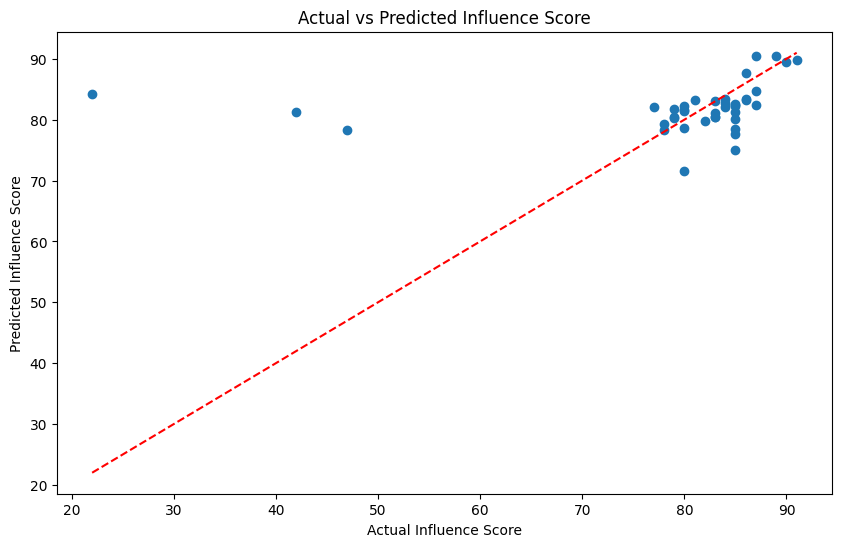

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Actual Influence Score")
plt.ylabel("Predicted Influence Score")
plt.title("Actual vs Predicted Influence Score")
plt.show()


# Classification: Engagement Rate (Low / Medium / High)


In [ ]:
#🔹 Step 1: Define Engagement Rate Classes
# Define bins and labels
bins = [0, 1, 3, df['60_day_eng_rate'].max()]
labels = ['Low', 'Medium', 'High']

# Create a new column for engagement class
df['engagement_rate_class'] = pd.cut(df['60_day_eng_rate'], bins=bins, labels=labels)

# Check the distribution
df['engagement_rate_class'].value_counts()


,count
engagement_rate_class,
Low,109
Medium,61
High,30


In [ ]:
#🔹 Step 2: Encode Categorical Data
from sklearn.preprocessing import LabelEncoder

# Encode 'country'
encoder = LabelEncoder()
df['country_encoded'] = encoder.fit_transform(df['country'])


In [ ]:
#🔹 Step 3: Prepare Features and Target

# Features and target
features = df[['followers', 'influence_score', 'country_encoded']]
target = df['engagement_rate_class']


In [ ]:
#🔹 Step 4: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


In [ ]:
#🔹 Step 5: Train Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Accuracy: 0.475

Classification Report:
               precision    recall  f1-score   support

        High       0.40      0.25      0.31         8
         Low       0.52      0.72      0.60        18
      Medium       0.40      0.29      0.33        14

    accuracy                           0.47        40
   macro avg       0.44      0.42      0.42        40
weighted avg       0.45      0.47      0.45        40



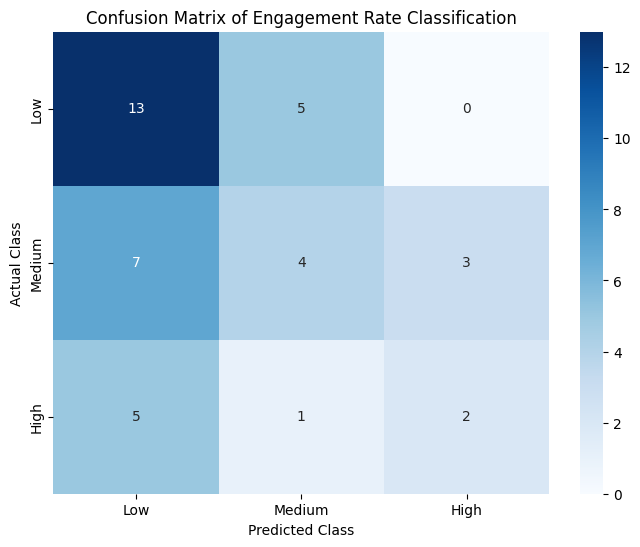

In [ ]:
#🔹 Step 6: Make Predictions and Evaluate
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = classifier.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=labels)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix of Engagement Rate Classification')
plt.show()
